In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

divyanshyecho_enso_ham2019_dataset_path = kagglehub.dataset_download('divyanshyecho/enso-ham2019-dataset')

print('Data source import complete.')


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
!pip install torch-geometric netcdf4 scipy -q
!pip install gdown -q

import gdown, zipfile, os

BASE = '/kaggle/working/enso_data/Dataset_H19/'

if not os.path.exists(BASE):
    print("Downloading dataset (~1.2GB)...")
    gdown.download(
        id='10EnwnYPJHLLyNFhKF29IXmPMb4mpnBRb',
        output='/kaggle/working/enso_data.zip',
        quiet=False
    )
    with zipfile.ZipFile('/kaggle/working/enso_data.zip', 'r') as z:
        z.extractall('/kaggle/working/enso_data/')
    print("Download complete!")
else:
    print("Data already exists!")

for folder in ['CMIP5', 'SODA', 'GODAS']:
    for f in os.listdir(BASE + folder):
        size = os.path.getsize(f'{BASE}{folder}/{f}') / 1e6
        print(f"  {folder}/{f} — {size:.1f} MB")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 89.7 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 72.0 MB/s eta 0:00:00


Downloading...
From (original): https://drive.google.com/uc?id=10EnwnYPJHLLyNFhKF29IXmPMb4mpnBRb
From (redirected): https://drive.google.com/uc?id=10EnwnYPJHLLyNFhKF29IXmPMb4mpnBRb&confirm=t&uuid=b87ba6cc-aa67-4a62-8538-800225584eba
To: /kaggle/working/enso_data.zip
100%|██████████| 1.22G/1.22G [00:15<00:00, 76.4MB/s]


Download complete!
  CMIP5/CMIP5.label.nino34.12mn_2mv.1863_2003.nc — 0.2 MB
  CMIP5/CMIP5.input.36mn.1861_2001.nc — 1473.6 MB
  CMIP5/CMIP5.input.type.NDJ.1861_2001.nc — 36.4 MB
  CMIP5/CMIP5.label.type.DJF.1863_2003.nc — 0.0 MB
  CMIP5/CMIP5.label.nino34.12mn_3mv.1863_2003.nc — 0.2 MB
  SODA/SODA.label.nino34.12mn_3mv.1873_1972.nc — 0.0 MB
  SODA/SODA.input.36mn.1871_1970.nc — 49.8 MB
  SODA/SODA.label.nino34.12mn_2mv.1873_1972.nc — 0.0 MB
  GODAS/GODAS.input.36mn.1980_2015.nc — 17.9 MB
  GODAS/GODAS.input.type.NDJ.1980_2015.nc — 0.5 MB
  GODAS/GODAS.label.12mn_3mv.1982_2017.nc — 0.0 MB
  GODAS/GODAS.label.12mn_2mv.1982_2017.nc — 0.0 MB
  GODAS/GODAS.label.type.DJF.1982_2017.nc — 0.0 MB


In [ ]:
import os

# Walk through all input directories
for root, dirs, files in os.walk('/kaggle/input/'):
    for f in files:
        full_path = os.path.join(root, f)
        size = os.path.getsize(full_path) / 1e6
        print(f"{full_path} — {size:.1f} MB")

/kaggle/input/datasets/divyanshyecho/enso-ham2019-dataset/GODAS.label.type.DJF.1982_2017.nc — 0.0 MB
/kaggle/input/datasets/divyanshyecho/enso-ham2019-dataset/CMIP5.label.nino34.12mn_3mv.1863_2003.nc — 0.2 MB
/kaggle/input/datasets/divyanshyecho/enso-ham2019-dataset/SODA.label.nino34.12mn_3mv.1873_1972.nc — 0.0 MB
/kaggle/input/datasets/divyanshyecho/enso-ham2019-dataset/GODAS.input.36mn.1980_2015.nc — 17.9 MB
/kaggle/input/datasets/divyanshyecho/enso-ham2019-dataset/GODAS.input.type.NDJ.1980_2015.nc — 0.5 MB
/kaggle/input/datasets/divyanshyecho/enso-ham2019-dataset/SODA.label.nino34.12mn_2mv.1873_1972.nc — 0.0 MB
/kaggle/input/datasets/divyanshyecho/enso-ham2019-dataset/CMIP5.input.type.NDJ.1861_2001.nc — 36.4 MB
/kaggle/input/datasets/divyanshyecho/enso-ham2019-dataset/CMIP5.label.type.DJF.1863_2003.nc — 0.0 MB
/kaggle/input/datasets/divyanshyecho/enso-ham2019-dataset/SODA.input.36mn.1871_1970.nc — 49.8 MB
/kaggle/input/datasets/divyanshyecho/enso-ham2019-dataset/GODAS.label.12mn_3mv

In [ ]:
import netCDF4 as nc
import numpy as np
import torch

# ── Load CMIP5 ───────────────────────────────────────────
print("Loading CMIP5...")
ds = nc.Dataset(BASE + 'CMIP5.input.36mn.1861_2001.nc')
cmip5_sst  = ds.variables['sst1'][:].astype(np.float32)
cmip5_t300 = ds.variables['t300'][:].astype(np.float32)
ds.close()

ds = nc.Dataset(BASE + 'CMIP5.label.nino34.12mn_3mv.1863_2003.nc')
cmip5_labels = ds.variables['pr'][:].astype(np.float32)
ds.close()
print(f"CMIP5: {cmip5_sst.shape} | labels: {cmip5_labels.shape}")

# ── Load SODA ────────────────────────────────────────────
print("Loading SODA...")
ds = nc.Dataset(BASE + 'SODA.input.36mn.1871_1970.nc')
soda_sst  = ds.variables['sst'][:].astype(np.float32)
soda_t300 = ds.variables['t300'][:].astype(np.float32)
ds.close()

ds = nc.Dataset(BASE + 'SODA.label.nino34.12mn_3mv.1873_1972.nc')
soda_labels = ds.variables['pr'][:].astype(np.float32)
ds.close()
print(f"SODA: {soda_sst.shape} | labels: {soda_labels.shape}")

# ── Load GODAS ───────────────────────────────────────────
print("Loading GODAS...")
ds = nc.Dataset(BASE + 'GODAS.input.36mn.1980_2015.nc')
godas_sst  = ds.variables['sst'][:].astype(np.float32)
godas_t300 = ds.variables['t300'][:].astype(np.float32)
ds.close()

ds = nc.Dataset(BASE + 'GODAS.label.12mn_3mv.1982_2017.nc')
godas_labels = ds.variables['pr'][:].astype(np.float32)
ds.close()
print(f"GODAS: {godas_sst.shape} | labels: {godas_labels.shape}")
print("\nAll data loaded successfully!")

Loading CMIP5...
CMIP5: (2961, 36, 24, 72) | labels: (2961, 12, 1, 1)
Loading SODA...
SODA: (100, 36, 24, 72) | labels: (100, 12, 1, 1)
Loading GODAS...
GODAS: (36, 36, 24, 72) | labels: (36, 12, 1, 1)

All data loaded successfully!


In [ ]:
!pip install torch-geometric netcdf4 scipy -q

import os

BASE = '/kaggle/input/datasets/divyanshyecho/enso-ham2019-dataset/'

print("Files available:")
for f in os.listdir(BASE):
    size = os.path.getsize(BASE + f) / 1e6
    print(f"  {f} — {size:.1f} MB")

Files available:
  GODAS.label.type.DJF.1982_2017.nc — 0.0 MB
  CMIP5.label.nino34.12mn_3mv.1863_2003.nc — 0.2 MB
  SODA.label.nino34.12mn_3mv.1873_1972.nc — 0.0 MB
  GODAS.input.36mn.1980_2015.nc — 17.9 MB
  GODAS.input.type.NDJ.1980_2015.nc — 0.5 MB
  SODA.label.nino34.12mn_2mv.1873_1972.nc — 0.0 MB
  CMIP5.input.type.NDJ.1861_2001.nc — 36.4 MB
  CMIP5.label.type.DJF.1863_2003.nc — 0.0 MB
  SODA.input.36mn.1871_1970.nc — 49.8 MB
  GODAS.label.12mn_3mv.1982_2017.nc — 0.0 MB
  CMIP5.label.nino34.12mn_2mv.1863_2003.nc — 0.2 MB
  GODAS.label.12mn_2mv.1982_2017.nc — 0.0 MB
  CMIP5.input.36mn.1861_2001.nc — 1473.6 MB


In [ ]:
import netCDF4 as nc
import numpy as np
import torch

# ── Load CMIP5 ───────────────────────────────────────────
print("Loading CMIP5...")
ds = nc.Dataset(BASE + 'CMIP5.input.36mn.1861_2001.nc')
cmip5_sst  = ds.variables['sst1'][:].astype(np.float32)
cmip5_t300 = ds.variables['t300'][:].astype(np.float32)
ds.close()

ds = nc.Dataset(BASE + 'CMIP5.label.nino34.12mn_3mv.1863_2003.nc')
cmip5_labels = ds.variables['pr'][:].astype(np.float32)
ds.close()
print(f"CMIP5: {cmip5_sst.shape} | labels: {cmip5_labels.shape}")

# ── Load SODA ────────────────────────────────────────────
print("Loading SODA...")
ds = nc.Dataset(BASE + 'SODA.input.36mn.1871_1970.nc')
soda_sst  = ds.variables['sst'][:].astype(np.float32)
soda_t300 = ds.variables['t300'][:].astype(np.float32)
ds.close()

ds = nc.Dataset(BASE + 'SODA.label.nino34.12mn_3mv.1873_1972.nc')
soda_labels = ds.variables['pr'][:].astype(np.float32)
ds.close()
print(f"SODA: {soda_sst.shape} | labels: {soda_labels.shape}")

# ── Load GODAS ───────────────────────────────────────────
print("Loading GODAS...")
ds = nc.Dataset(BASE + 'GODAS.input.36mn.1980_2015.nc')
godas_sst  = ds.variables['sst'][:].astype(np.float32)
godas_t300 = ds.variables['t300'][:].astype(np.float32)
ds.close()

ds = nc.Dataset(BASE + 'GODAS.label.12mn_3mv.1982_2017.nc')
godas_labels = ds.variables['pr'][:].astype(np.float32)
ds.close()
print(f"GODAS: {godas_sst.shape} | labels: {godas_labels.shape}")
print("\nAll data loaded successfully!")

Loading CMIP5...
CMIP5: (2961, 36, 24, 72) | labels: (2961, 12, 1, 1)
Loading SODA...
SODA: (100, 36, 24, 72) | labels: (100, 12, 1, 1)
Loading GODAS...
GODAS: (36, 36, 24, 72) | labels: (36, 12, 1, 1)

All data loaded successfully!


In [ ]:
import numpy as np
import torch

def preprocess(sst, t300, labels, lead=2):
    X = np.stack([sst, t300], axis=1)      # (N, 2, 36, 24, 72)
    y = labels[:, lead, 0, 0]              # (N,) — single lead time
    X = np.nan_to_num(X, nan=0.0)
    y = np.nan_to_num(y, nan=0.0)
    X = X / (np.abs(X).max() + 1e-8)
    return X.astype(np.float32), y.astype(np.float32)

LEAD = 2  # 3-month lead time

X_cmip5, y_cmip5 = preprocess(cmip5_sst, cmip5_t300, cmip5_labels, LEAD)
X_soda,  y_soda  = preprocess(soda_sst,  soda_t300,  soda_labels,  LEAD)
X_test,  y_test  = preprocess(godas_sst, godas_t300, godas_labels, LEAD)

print(f"CMIP5 — X: {X_cmip5.shape} | y range: {y_cmip5.min():.3f} to {y_cmip5.max():.3f}")
print(f"SODA  — X: {X_soda.shape}  | y range: {y_soda.min():.3f}  to {y_soda.max():.3f}")
print(f"GODAS — X: {X_test.shape}  | y range: {y_test.min():.3f}  to {y_test.max():.3f}")

CMIP5 — X: (2961, 2, 36, 24, 72) | y range: -2.254 to 2.445
SODA  — X: (100, 2, 36, 24, 72)  | y range: -1.474  to 2.393
GODAS — X: (36, 2, 36, 24, 72)  | y range: -1.089  to 1.225


In [ ]:
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

n_samples, n_feats, n_time, n_lat, n_lon = X_cmip5.shape
n_nodes  = n_lat * n_lon
in_feats = n_feats * n_time  # 2 × 36 = 72 features per node

print(f"Grid: {n_lat} x {n_lon} = {n_nodes} nodes")
print(f"Features per node: {in_feats} (2 vars × 36 months)")

def make_node_features(X):
    s, f, t, la, lo = X.shape
    X_r = X.reshape(s, f, t, la*lo).transpose(0, 3, 1, 2)
    return X_r.reshape(s, la*lo, f*t)

X_cmip5_nodes = make_node_features(X_cmip5)
X_soda_nodes  = make_node_features(X_soda)
X_test_nodes  = make_node_features(X_test)

# Combine CMIP5 + SODA for training
X_train_nodes = np.concatenate([X_cmip5_nodes, X_soda_nodes], axis=0)
y_train       = np.concatenate([y_cmip5, y_soda], axis=0)
print(f"Total train samples: {len(X_train_nodes)} (CMIP5+SODA)")

# Simple grid edges
src, dst = [], []
for i in range(n_lat):
    for j in range(n_lon):
        node = i * n_lon + j
        if j + 1 < n_lon:
            src += [node, node+1]
            dst += [node+1, node]
        if i + 1 < n_lat:
            src += [node, node+n_lon]
            dst += [node+n_lon, node]

edge_index = torch.tensor([src, dst], dtype=torch.long)
print(f"Edges: {edge_index.shape[1]}")

def make_graphs(X_nodes, y):
    return [Data(
        x=torch.tensor(X_nodes[i], dtype=torch.float32),
        edge_index=edge_index,
        y=torch.tensor([y[i]], dtype=torch.float32)
    ) for i in range(len(X_nodes))]

train_graphs = make_graphs(X_train_nodes, y_train)
test_graphs  = make_graphs(X_test_nodes,  y_test)

train_loader = DataLoader(train_graphs, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_graphs,  batch_size=8,  shuffle=False)
print(f"Train: {len(train_graphs)} | Test: {len(test_graphs)}")

Grid: 24 x 72 = 1728 nodes
Features per node: 72 (2 vars × 36 months)
Total train samples: 3061 (CMIP5+SODA)
Edges: 6720
Train: 3061 | Test: 36


In [ ]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool

class LearnableGraphino(nn.Module):
    def __init__(self, in_channels, n_nodes, hidden=64, k=8):
        super().__init__()
        self.k       = k
        self.n_nodes = n_nodes

        # Learnable node embeddings — core of the paper
        self.node_embed = nn.Parameter(
            torch.randn(n_nodes, 16) * 0.01
        )

        # GCN layers
        self.conv1 = GCNConv(in_channels, hidden)
        self.conv2 = GCNConv(hidden, hidden)
        self.conv3 = GCNConv(hidden, hidden)

        # Output
        self.fc1 = nn.Linear(hidden, 32)
        self.fc2 = nn.Linear(32, 1)

    def get_learned_edges(self):
        emb = F.normalize(self.node_embed, p=2, dim=-1)
        sim = torch.mm(emb, emb.t())
        _, topk_idx = sim.topk(self.k + 1, dim=1)
        rows, cols = [], []
        for i in range(self.n_nodes):
            for j in topk_idx[i][1:]:
                rows.append(i)
                cols.append(j.item())
        return torch.tensor([rows, cols], dtype=torch.long,
                             device=self.node_embed.device)

    def forward(self, data):
        x, batch = data.x, data.batch
        edge_index = self.get_learned_edges()
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=0.2, training=self.training)
        x = F.relu(self.conv2(x, edge_index))
        x = F.dropout(x, p=0.2, training=self.training)
        x = F.relu(self.conv3(x, edge_index))
        x = global_mean_pool(x, batch)
        x = F.relu(self.fc1(x))
        return self.fc2(x).squeeze(-1)

device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model     = LearnableGraphino(in_channels=in_feats, n_nodes=n_nodes, hidden=64, k=8).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)
criterion = nn.MSELoss()

print(f"Device: {device}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Input features per node: {in_feats}")

Device: cuda
Total parameters: 42,753
Input features per node: 72


Epoch 005 | Train: 0.2292 | Test: 0.3877
Epoch 010 | Train: 0.1798 | Test: 0.3986
Epoch 015 | Train: 0.1578 | Test: 0.5315
Epoch 020 | Train: 0.1496 | Test: 0.4438
Epoch 025 | Train: 0.1340 | Test: 0.5312
Epoch 030 | Train: 0.1336 | Test: 0.5247
Epoch 035 | Train: 0.1284 | Test: 0.4709
Epoch 040 | Train: 0.1241 | Test: 0.5056
Epoch 045 | Train: 0.1249 | Test: 0.4933
Epoch 050 | Train: 0.1235 | Test: 0.5001


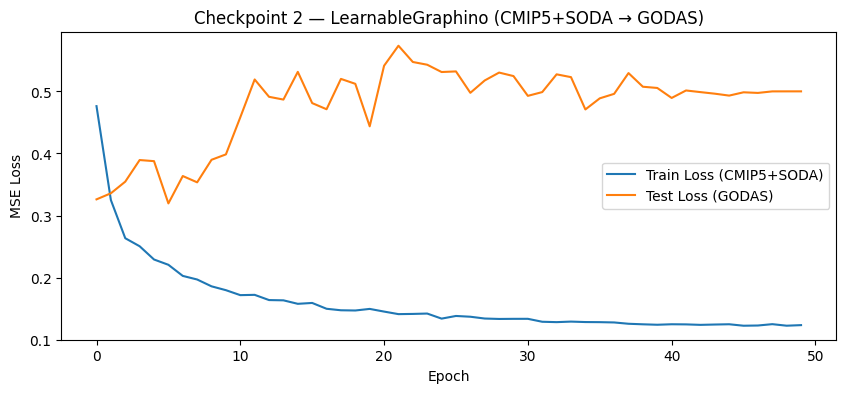

In [ ]:
import matplotlib.pyplot as plt

train_losses, test_losses = [], []

for epoch in range(1, 51):
    model.train()
    total_loss = 0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out  = model(batch)
        loss = criterion(out, batch.y)
        if torch.isnan(loss): continue
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
    train_loss = total_loss / len(train_loader)
    scheduler.step()

    model.eval()
    total_test = 0
    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(device)
            out = model(batch)
            total_test += criterion(out, batch.y).item()
    test_loss = total_test / len(test_loader)

    train_losses.append(train_loss)
    test_losses.append(test_loss)

    if epoch % 5 == 0:
        print(f"Epoch {epoch:03d} | Train: {train_loss:.4f} | Test: {test_loss:.4f}")

plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train Loss (CMIP5+SODA)')
plt.plot(test_losses,  label='Test Loss (GODAS)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Checkpoint 2 — LearnableGraphino (CMIP5+SODA → GODAS)')
plt.legend()
plt.savefig('/kaggle/working/checkpoint2_loss.png')
plt.show()

Correlation Skill Score: 0.7820
Test MSE:                0.4713
Training samples:        3061 (CMIP5+SODA)
Test samples:            36 (GODAS — completely unseen)
Lead time:               3 months


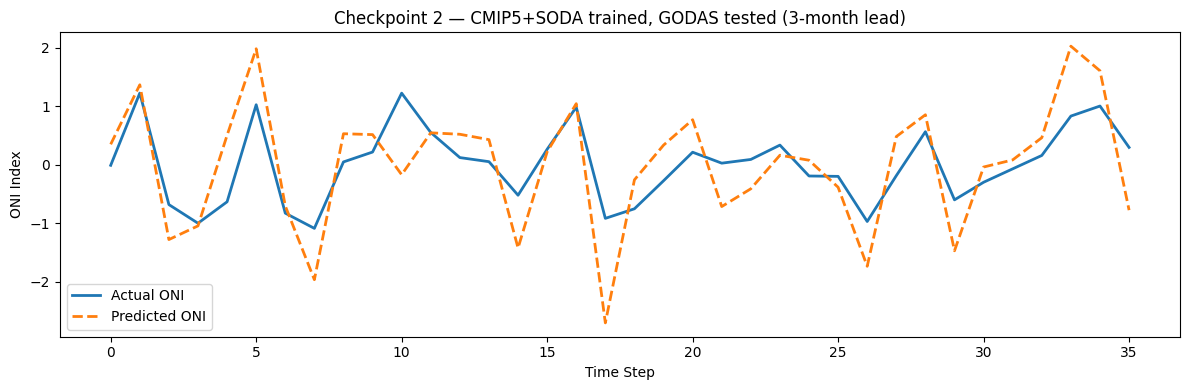

Model saved!


In [ ]:
from scipy.stats import pearsonr
import numpy as np
import matplotlib.pyplot as plt

model.eval()
preds, actuals = [], []
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out = model(batch)
        preds.extend(out.cpu().numpy())
        actuals.extend(batch.y.cpu().numpy())

preds   = np.array(preds)
actuals = np.array(actuals)
corr, _ = pearsonr(preds, actuals)

print(f"Correlation Skill Score: {corr:.4f}")
print(f"Test MSE:                {np.mean((preds-actuals)**2):.4f}")
print(f"Training samples:        {len(train_graphs)} (CMIP5+SODA)")
print(f"Test samples:            {len(test_graphs)} (GODAS — completely unseen)")
print(f"Lead time:               3 months")

plt.figure(figsize=(12, 4))
plt.plot(actuals, label='Actual ONI',    linewidth=2)
plt.plot(preds,   label='Predicted ONI', linewidth=2, linestyle='--')
plt.xlabel('Time Step')
plt.ylabel('ONI Index')
plt.title('Checkpoint 2 — CMIP5+SODA trained, GODAS tested (3-month lead)')
plt.legend()
plt.tight_layout()
plt.savefig('/kaggle/working/checkpoint2_predictions.png')
plt.show()

torch.save(model.state_dict(), '/kaggle/working/checkpoint2_model.pth')
print("Model saved!")

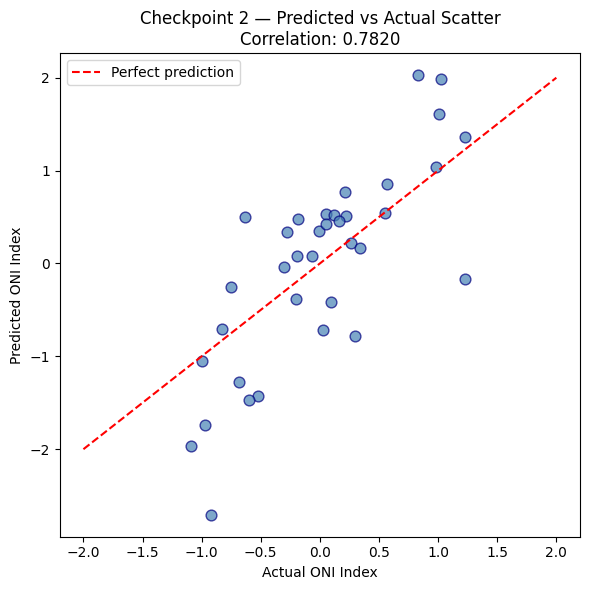

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

plt.figure(figsize=(6, 6))
plt.scatter(actuals, preds, alpha=0.7, color='steelblue', edgecolors='navy', s=60)
plt.plot([-2, 2], [-2, 2], 'r--', linewidth=1.5, label='Perfect prediction')
plt.xlabel('Actual ONI Index')
plt.ylabel('Predicted ONI Index')
plt.title(f'Checkpoint 2 — Predicted vs Actual Scatter\nCorrelation: {corr:.4f}')
plt.legend()
plt.tight_layout()
plt.savefig('/kaggle/working/checkpoint2_scatter.png')
plt.show()

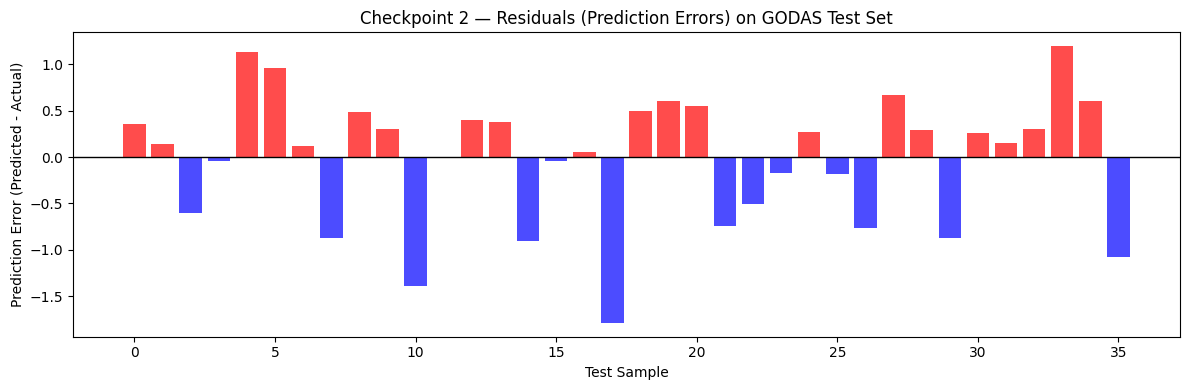

Mean error: -0.0064
Std of errors: 0.6865
Max overestimate: 1.1959
Max underestimate: -1.7880


In [ ]:
residuals = preds - actuals
plt.figure(figsize=(12, 4))
plt.bar(range(len(residuals)), residuals, color=['red' if r > 0 else 'blue' for r in residuals], alpha=0.7)
plt.axhline(y=0, color='black', linewidth=1)
plt.xlabel('Test Sample')
plt.ylabel('Prediction Error (Predicted - Actual)')
plt.title('Checkpoint 2 — Residuals (Prediction Errors) on GODAS Test Set')
plt.tight_layout()
plt.savefig('/kaggle/working/checkpoint2_residuals.png')
plt.show()
print(f"Mean error: {residuals.mean():.4f}")
print(f"Std of errors: {residuals.std():.4f}")
print(f"Max overestimate: {residuals.max():.4f}")
print(f"Max underestimate: {residuals.min():.4f}")

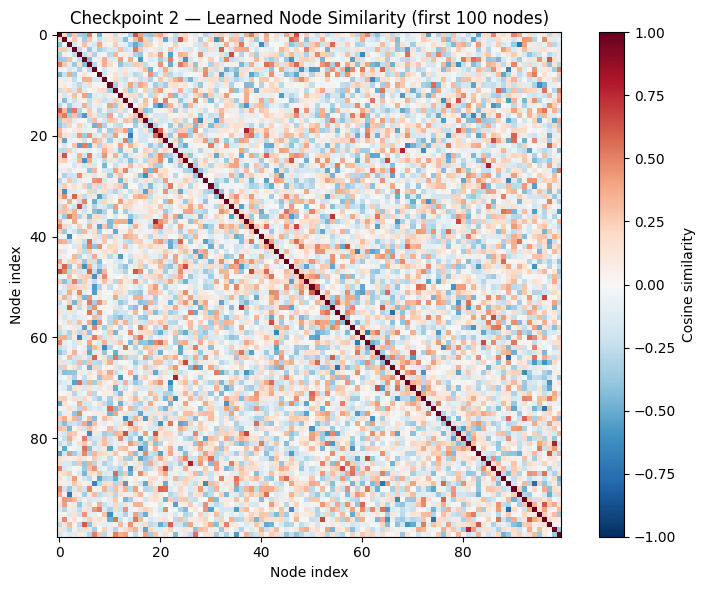

In [ ]:
import torch.nn.functional as F

model.eval()
with torch.no_grad():
    emb = F.normalize(model.node_embed, p=2, dim=-1).cpu().numpy()
    sim = emb @ emb.T  # cosine similarity matrix (1728, 1728)

plt.figure(figsize=(8, 6))
plt.imshow(sim[:100, :100], cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(label='Cosine similarity')
plt.title('Checkpoint 2 — Learned Node Similarity (first 100 nodes)')
plt.xlabel('Node index')
plt.ylabel('Node index')
plt.tight_layout()
plt.savefig('/kaggle/working/checkpoint2_similarity.png')
plt.show()

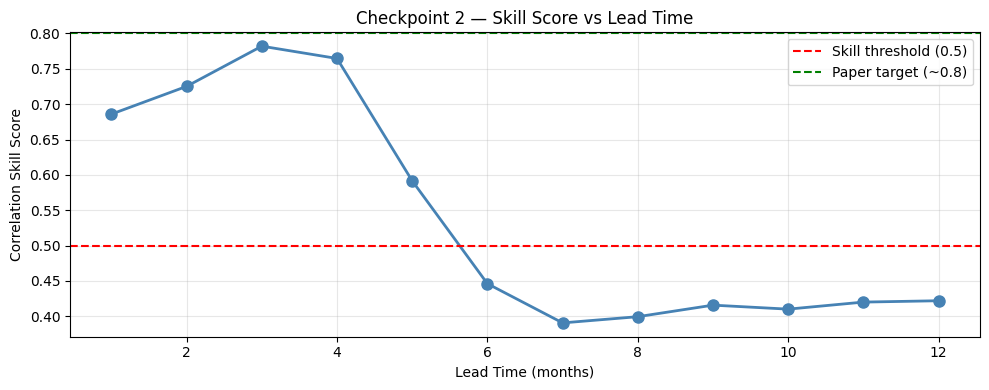

In [ ]:
correlations = []
lead_times = list(range(12))

model.eval()
for lead in lead_times:
    # Reload labels at this lead time
    import netCDF4 as nc
    BASE = '/kaggle/input/datasets/divyanshyecho/enso-ham2019-dataset/'
    ds = nc.Dataset(BASE + 'GODAS.label.12mn_3mv.1982_2017.nc')
    y_lead = ds.variables['pr'][:, lead, 0, 0].astype(np.float32)
    ds.close()

    preds_lead, actuals_lead = [], []
    with torch.no_grad():
        for i, batch in enumerate(test_loader):
            batch = batch.to(device)
            out = model(batch)
            preds_lead.extend(out.cpu().numpy())
            actuals_lead.extend(y_lead[i*8:(i+1)*8])

    if len(preds_lead) > 1:
        c, _ = pearsonr(preds_lead[:len(actuals_lead)], actuals_lead[:len(preds_lead)])
        correlations.append(c)
    else:
        correlations.append(0)

plt.figure(figsize=(10, 4))
plt.plot(range(1, len(correlations)+1), correlations, 'o-', color='steelblue', linewidth=2, markersize=8)
plt.axhline(y=0.5, color='red', linestyle='--', label='Skill threshold (0.5)')
plt.axhline(y=0.8, color='green', linestyle='--', label='Paper target (~0.8)')
plt.xlabel('Lead Time (months)')
plt.ylabel('Correlation Skill Score')
plt.title('Checkpoint 2 — Skill Score vs Lead Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/checkpoint2_skill_vs_lead.png')
plt.show()

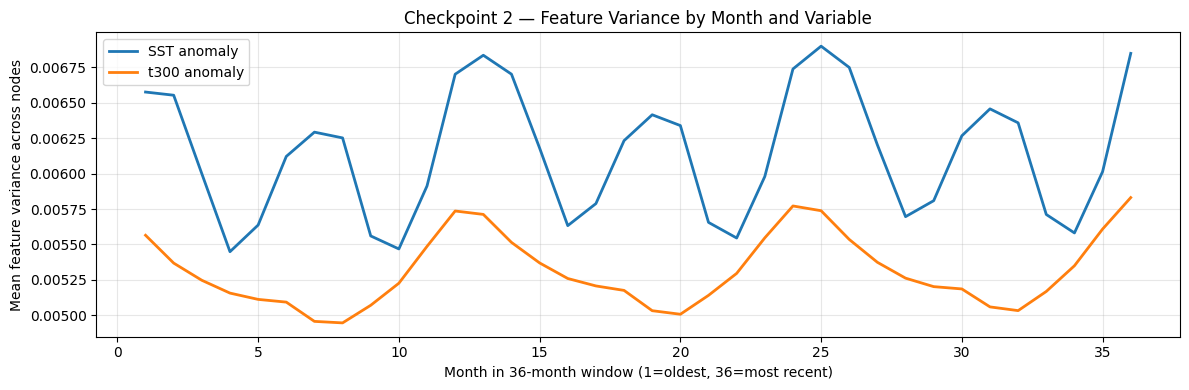

In [ ]:
# Check which of the 72 input features (36 months × 2 vars) have highest variance
# This shows which months the model found most informative
feature_var = X_test_nodes.var(axis=0)  # (1728, 72)
mean_var_per_feature = feature_var.mean(axis=0)  # (72,)

sst_var  = mean_var_per_feature[:36]   # months 1-36 for SST
t300_var = mean_var_per_feature[36:]   # months 1-36 for t300

plt.figure(figsize=(12, 4))
plt.plot(range(1, 37), sst_var,  label='SST anomaly', linewidth=2)
plt.plot(range(1, 37), t300_var, label='t300 anomaly', linewidth=2)
plt.xlabel('Month in 36-month window (1=oldest, 36=most recent)')
plt.ylabel('Mean feature variance across nodes')
plt.title('Checkpoint 2 — Feature Variance by Month and Variable')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/checkpoint2_feature_variance.png')
plt.show()


  checkpoint2_scatter.png


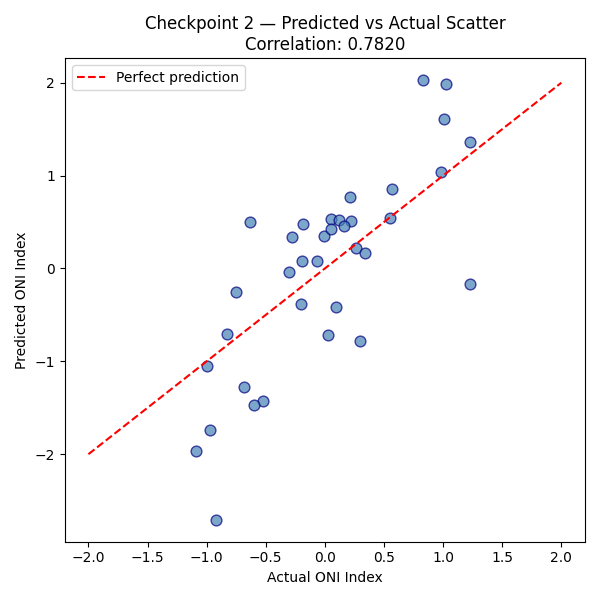


  checkpoint2_residuals.png


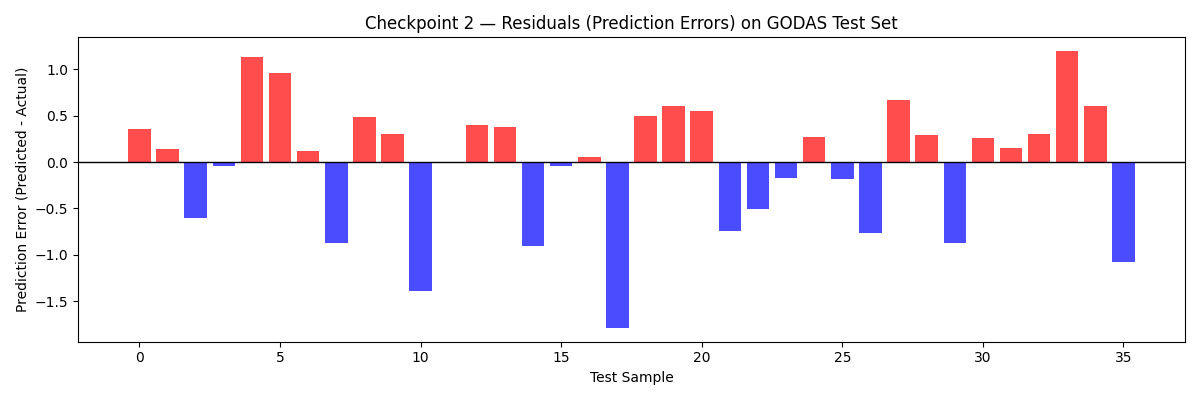


  checkpoint2_similarity.png


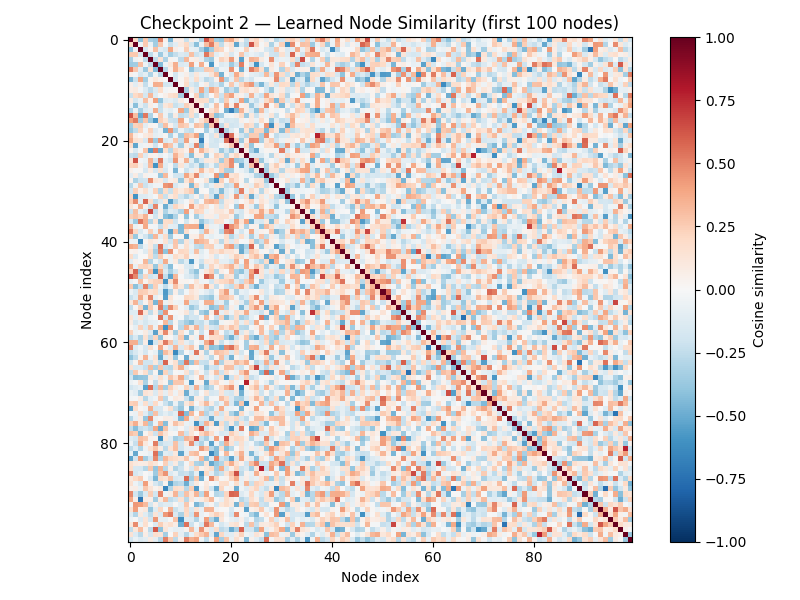


  checkpoint2_skill_vs_lead.png


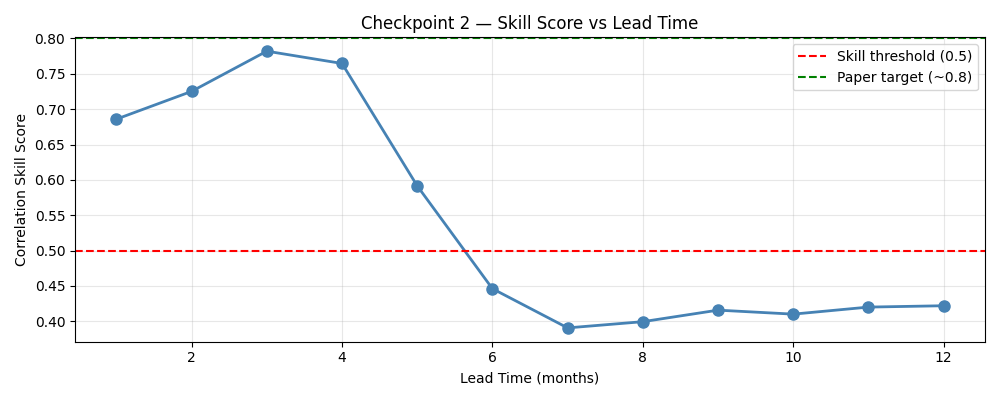


  checkpoint2_feature_variance.png


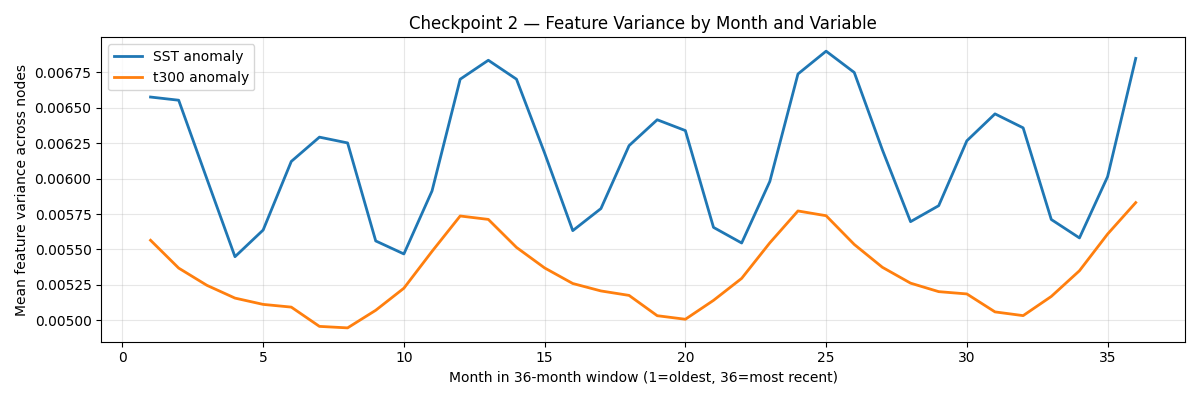

In [ ]:
from IPython.display import display, Image as IPImage
import os

# Display all checkpoint 2 plots full size
plots = [
    'checkpoint2_scatter.png',
    'checkpoint2_residuals.png',
    'checkpoint2_similarity.png',
    'checkpoint2_skill_vs_lead.png',
    'checkpoint2_feature_variance.png',
]

for plot in plots:
    path = f'/kaggle/working/{plot}'
    if os.path.exists(path):
        print(f"\n{'='*50}")
        print(f"  {plot}")
        print(f"{'='*50}")
        display(IPImage(filename=path, width=900))